# 07 — The decision rule, ensembling, and knowing when to stop

After the feature road ends (notebook 06), three moves remain: correct the decision for
the metric, buy diversity by ensembling, and then select. This notebook is where the
competition was actually won and lost, so section 1 is deliberately slow: the rule is
**derived from the metric**, checked against the data, and then measured for
overfitting. It is worth +0.077 here — twenty times everything else in the ladder
combined — and it is the one piece of this project that transfers unchanged to any
imbalanced-classification problem.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import polars as pl

from s6e7 import cv, decision, features, io, metric, plots
from s6e7.cv import ExperimentConfig

pl.Config.set_tbl_width_chars(220)
pl.Config.set_fmt_str_lengths(90)
train, test = io.load_train(), io.load_test()
y = features.encode_target(train[io.TARGET])
proba7 = np.load(cv.OOF_DIR / "exp_0007.npy")     # the best argmax model, before any rule

---
## 1. The rule, derived

### 1.1 The metric has a price list

Balanced accuracy is the mean of the per-class recalls — nothing else:

$$\mathrm{BA} \;=\; \frac{1}{K}\sum_{k=1}^{K}\frac{\text{hit}_k}{n_k}$$

`hit_k` is how many rows of class *k* we labelled *k*, and `n_k` is how many exist. Read
that as a price list: labelling one more row of class *k* correctly adds exactly
`1 / (K · n_k)` to the score. The price depends on the *class*, not on the model, not on
the row, and not on how confident anything was.

In [2]:
decision.exchange_table(y)

class,n_rows,prior,ba_per_correct_row,worth_vs_majority
str,i64,f64,f64,f64
"""at-risk""",592561,0.858675,5.6253e-7,1.0
"""fit""",39803,0.057678,0.000008,14.887345
"""unhealthy""",57724,0.083647,0.000006,10.265418


Three prices, and their ratio is the whole story:

| one more correct row of | adds to BA | worth, vs one `at-risk` row |
|---|---|---|
| `at-risk` (592,561 rows) | 0.00000056 | 1 |
| `fit` (39,803 rows) | 0.0000084 | **14.9** |
| `unhealthy` (57,724 rows) | 0.0000058 | **10.3** |

So the metric will happily hand over 15 correct `at-risk` rows for one correct `fit`
row and call it break-even. **Argmax refuses that trade** — it maximises the count of
correct rows, which treats all three as worth 1. Argmax is the right rule for plain
accuracy and the wrong rule here, and no amount of extra trees fixes a wrong rule.

### 1.2 The rule that takes the trade

Write recall as an expectation over rows. For class *k*, with `q_k(x)` the model's
probability and `pi_k = n_k / N` the class prior:

$$P(\hat{y}=k \mid y=k) \;=\; \frac{P(\hat{y}=k,\; y=k)}{\pi_k} \;=\; \frac{1}{\pi_k}\,\mathbb{E}_x\big[\,q_k(x)\,\mathbf{1}[d(x)=k]\,\big]$$

Substituting into BA and pulling the expectation out front:

$$\mathrm{BA} \;=\; \mathbb{E}_x\Big[\;\sum_k \frac{q_k(x)}{K\,\pi_k}\,\mathbf{1}[d(x)=k]\;\Big]$$

Inside the brackets exactly one indicator fires per row, so there is no interaction
between rows: the expectation is maximised by maximising each row separately, picking
the largest coefficient available for that row.

$$d^{*}(x) \;=\; \arg\max_k \frac{q_k(x)}{\pi_k} \;=\; \arg\max_k \; m_k\, q_k(x), \qquad m_k = \frac{1}{\pi_k}$$

Nothing was fitted. The multipliers **are** the price list from 1.1: dividing by the
prior *is* taking the trade. And because scaling all three multipliers cannot change an
argmax, only their ratios matter — fixing `m[at-risk] = 1` leaves K−1 = 2 numbers, which
is why everything below is a 2-dimensional picture.

Here is one real OOF row where the two rules disagree:

In [3]:
m_prior = decision.prior_multipliers(y)
row = 430446                       # an `unhealthy` row that argmax calls `at-risk`
print(f"{'class':12s} {'m (= 1/prior)':>14s} {'q (model)':>10s} {'m . q':>10s}")
for k, cls in enumerate(io.CLASSES):
    print(f"{cls:12s} {m_prior[k]:14.3f} {proba7[row, k]:10.4f} {proba7[row, k] * m_prior[k]:10.4f}")
print(f"\nargmax says {io.CLASSES[proba7[row].argmax()]!r}, "
      f"the rule says {io.CLASSES[decision.apply(proba7[row][None], m_prior)[0]]!r}, "
      f"truth is {train[io.TARGET][row]!r}")

class         m (= 1/prior)  q (model)      m . q
at-risk               1.000     0.9095     0.9095
fit                  14.887     0.0001     0.0009
unhealthy            10.265     0.0905     0.9289

argmax says 'at-risk', the rule says 'unhealthy', truth is 'unhealthy'


The model is **91% sure** this person is `at-risk` and gives `unhealthy` only 9%. The
rule labels it `unhealthy` anyway, because a correct `unhealthy` is worth 10.3× a
correct `at-risk`: 0.0905 × 10.265 = 0.929 beats 0.9095 × 1. Note how *narrow* that
margin is — 2%. Rows well inside either class are untouched; the rule only re-labels
rows near the new boundary, which is why it moves tens of thousands of rows and not
hundreds of thousands.

### 1.3 Two routes to the same correction

The correction can be applied at either end of training, and one experiment each:

- **Route A — during training:** `class_weight="balanced"` scales each class's loss
  contribution by `1/pi_k`, so the model's own argmax already encodes the trade.
- **Route B — after training:** leave the model alone and search the multipliers on the
  OOF probabilities. Two free parameters, coarse-to-fine log grid, and — the honesty
  part — **cross-fitted**: the multipliers each fold is judged with were searched
  without that fold.

In [4]:
route_a = cv.run(ExperimentConfig(
    "exp_0008", "lgbm",
    {"categorical_feature": features.CATEGORICAL_IDX, "n_estimators": 500,
     "learning_rate": 0.05, "class_weight": "balanced"},
    features="native_cats", parent="exp_0007",
    changed="route A: class_weight=balanced on the combo (training-route prior correction)"),
    train=train, test=test, if_logged="skip")
route_b, m_b = cv.run_rule("exp_0009", "exp_0007", train=train)
print(f"route A (weights): cv {route_a.cv_mean:.5f} +/- {route_a.cv_std:.5f}")
print(f"route B (rule):    cv {route_b.cv_mean:.5f} +/- {route_b.cv_std:.5f}   "
      f"searched multipliers {np.round(m_b, 2).tolist()}  vs 1/prior {np.round(m_prior, 2).tolist()}")

route A (weights): cv 0.94945 +/- 0.00108
route B (rule):    cv 0.94931 +/- 0.00115   searched multipliers [1.0, 17.22, 10.16]  vs 1/prior [1.0, 14.89, 10.27]


**A dead heat, as the derivation predicts.** The two routes implement the same trade and
land 0.00014 apart — far inside the 0.001 resolution. The searched multipliers
(1, 17.2, 10.2) sit close to the derived (1, 14.9, 10.3); section 1.5 shows that the
remaining distance is worth almost nothing.

**This one decision was worth +0.077.** For scale: encoding bought +0.0009, capacity
+0.0039, two feature ideas +0.0000, ensembling ~0. Everything else in the ladder is
noise next to matching the decision to the metric — and it was visible in the very first
confusion matrix (notebook 04), not discovered by search.

### 1.4 What the correction costs, and what it buys

A prior correction is a *trade*, so the diagnostic is the two sides of it, in rows:

In [5]:
effect = decision.rule_effect(proba7, y, m_b)
print(effect)

price = decision.exchange_table(y)["ba_per_correct_row"].to_numpy()
moved = effect["rows_gained"].to_numpy()
for cls, rows, p in zip(io.CLASSES, moved, price):
    print(f"  {cls:10s} {rows:+7d} rows  x {p:.3e} = {rows * p:+.5f} BA")
print(f"  {'net':10s} {'':13s}               = {(moved * price).sum():+.5f} BA")
print(f"  measured   argmax {cv.result_from_oof('exp_0007', train=train).cv_mean:.5f} "
      f"-> rule {metric.balanced_accuracy(y, decision.apply(proba7, m_b)):.5f}")

shape: (3, 6)
┌───────────┬────────┬───────────────┬─────────────┬───────────┬─────────────┐
│ class     ┆ n_rows ┆ recall_argmax ┆ recall_rule ┆ delta     ┆ rows_gained │
│ ---       ┆ ---    ┆ ---           ┆ ---         ┆ ---       ┆ ---         │
│ str       ┆ i64    ┆ f64           ┆ f64         ┆ f64       ┆ i64         │
╞═══════════╪════════╪═══════════════╪═════════════╪═══════════╪═════════════╡
│ at-risk   ┆ 592561 ┆ 0.991606      ┆ 0.935894    ┆ -0.055712 ┆ -33013      │
│ fit       ┆ 39803  ┆ 0.831395      ┆ 0.948974    ┆ 0.117579  ┆ 4680        │
│ unhealthy ┆ 57724  ┆ 0.809247      ┆ 0.963377    ┆ 0.15413   ┆ 8897        │
└───────────┴────────┴───────────────┴─────────────┴───────────┴─────────────┘
  at-risk     -33013 rows  x 5.625e-07 = -0.01857 BA
  fit          +4680 rows  x 8.375e-06 = +0.03919 BA
  unhealthy    +8897 rows  x 5.775e-06 = +0.05138 BA
  net                                    = +0.07200 BA


  measured   argmax 0.87742 -> rule 0.94941


The trade, in one line: **give up 33,013 correct `at-risk` rows to gain 4,680 `fit` and
8,897 `unhealthy` rows.** In raw accuracy that is a disaster — 19,436 more rows wrong
overall. In balanced accuracy the cheap rows cost −0.0186 and the expensive rows pay
+0.0906, for a net +0.072 that matches the measured jump 0.87742 → 0.94941.

That identity is the check to run on any post-processing you ever apply: if the
per-class row counts times the metric's price list do not reproduce the score change,
you have misunderstood either the rule or the metric.

Also note the shape: `at-risk` recall falls 0.992 → 0.936 while both minorities rise
past 0.94. **If the majority-class loss is not the biggest single number in that table,
the multipliers are doing something other than correcting the prior** — and you should
find out what before trusting them.

### 1.5 Is the search a fit, or a plateau?

Route B *searched* two parameters on data, so it owes the same answer as any fit. Rather
than argue, price the three rules on the same probabilities and then look at the entire
objective surface — balanced accuracy at every `(m_fit, m_unhealthy)` on the grid:

In [6]:
for name, m in [("argmax  (0 params)", np.ones(3)),
                ("1/prior (0 params)", m_prior),
                ("searched (2 params)", m_b)]:
    print(f"{name:20s} m = {str(np.round(m, 3).tolist()):26s} "
          f"BA = {metric.balanced_accuracy(y, decision.apply(proba7, m)):.5f}")

argmax  (0 params)   m = [1.0, 1.0, 1.0]            BA = 0.87742
1/prior (0 params)   m = [1.0, 14.887, 10.265]      BA = 0.94932
searched (2 params)  m = [1.0, 17.223, 10.161]      BA = 0.94941


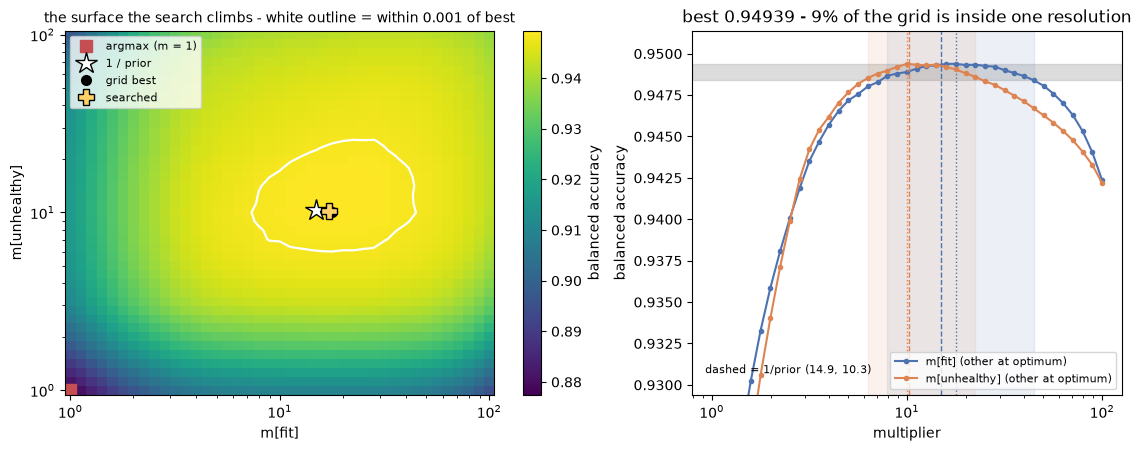

In [7]:
plots.rule_landscape(proba7, y, size=41, searched=m_b)

**The theory is worth +0.0719. The search is worth +0.00009** — one tenth of the
resolution, i.e. nothing this harness can see. The white outline is the set of
multipliers scoring within one resolution of the best, and it covers **9% of a
100×100-fold parameter box**: `m_fit` anywhere in ~6–40 and `m_unhealthy` anywhere in
~4–20 give the same answer.

That is the useful shape of this result. A *narrow* peak far from `1/prior` would have
meant the search was repairing calibration error, and every downstream use of it would
need careful cross-fitting. A *wide* plateau containing `1/prior` means the search
merely re-found the theory — which is also what notebook 04's reliability curves
predicted, since well-calibrated probabilities leave the derivation intact.

### 1.6 The overfitting question — and what per-fold spread actually means

Two measurements. First, the built-in one: `search` maximises the metric on the rows it
sees (in-sample), `cross_fit` searches on four folds and scores on the fifth (honest).
The gap between them *is* the overfitting.

In [8]:
_, in_sample = decision.search(proba7, y)
cache = json.loads((cv.OOF_DIR / "exp_0009_rule.json").read_text())
print(f"in-sample search: {in_sample:.5f}   cross-fitted: {route_b.cv_mean:.5f}   "
      f"gap: {in_sample - route_b.cv_mean:+.5f}")
print("per-fold searched multipliers:")
for k, m in enumerate(cache["fold_multipliers"]):
    print(f"  fold {k}: {m}")

in-sample search: 0.94941   cross-fitted: 0.94931   gap: +0.00011
per-fold searched multipliers:
  fold 0: [1.0, 17.223, 10.161]
  fold 1: [1.0, 17.223, 13.769]
  fold 2: [1.0, 17.223, 10.161]
  fold 3: [1.0, 16.156, 10.161]
  fold 4: [1.0, 16.156, 10.161]


In [9]:
lo, hi = np.array(cache["fold_multipliers"][0]), np.array(cache["fold_multipliers"][1])
labels_lo, labels_hi = decision.apply(proba7, lo), decision.apply(proba7, hi)
print(f"m[unhealthy] differs by {hi[2] / lo[2]:.2f}x  ({lo[2]} vs {hi[2]})")
print(f"  labels differ on {int((labels_lo != labels_hi).sum()):,} rows "
      f"= {100 * (labels_lo != labels_hi).mean():.2f}% of train")
print(f"  balanced accuracy {metric.balanced_accuracy(y, labels_lo):.5f} vs "
      f"{metric.balanced_accuracy(y, labels_hi):.5f}")

m[unhealthy] differs by 1.36x  (10.161 vs 13.769)
  labels differ on 2,941 rows = 0.43% of train


  balanced accuracy 0.94941 vs 0.94935


The gap is +0.0001 — two parameters against ~550k rows per search, so a rounding error.
The rule is not overfitting.

But look at the per-fold multipliers honestly: `m_fit` spans 16.2–17.2 (6%) and
`m_unhealthy` spans 10.2–13.8 (**36%**). Five searches on 80% samples of the same data
did *not* agree on the parameter. The instinct is to call that instability — and the
second cell shows why it is not: swapping the most extreme pair of fold multipliers
changes 0.43% of the labels and moves the score by 0.00006, six percent of one
resolution.

**Parameter spread and score spread are different things, and only the second one
matters.** A flat objective has no unique argmax to be stable about; the white plateau
in the figure above *is* that flatness, drawn. So the stability check for any tuned
post-processing is "does the *score* move", never "do the *parameters* agree" — and the
general answer to *"is this overfitting or really helping?"* stays the same: hold out
the rows you tuned on, and compare in-sample to held-out.

---
## 2. Ensembling: diversity is a measurement, not a hope

A blend beats its best member only where the members' *errors* decorrelate. Two models
that are wrong on the same rows average to the same wrongness. So price the diversity
before buying models:

In [10]:
labels_lgbm = proba7.argmax(1)
labels_xgb = np.load(cv.OOF_DIR / "exp_0010.npy").argmax(1)
err_l, err_x = labels_lgbm != y, labels_xgb != y
print(f"error rate  lgbm {err_l.mean():.4f}   xgb {err_x.mean():.4f}")
print(f"both wrong  observed {(err_l & err_x).mean():.4f}   "
      f"if independent {err_l.mean() * err_x.mean():.4f}")
print(f"error correlation {np.corrcoef(err_l, err_x)[0, 1]:.3f}")

error rate  lgbm 0.0329   xgb 0.0330


both wrong  observed 0.0293   if independent 0.0011
error correlation 0.885


In [11]:
blend = cv.run_blend("exp_0011", ["exp_0007", "exp_0010"], train=train)
ruled_blend, m_blend = cv.run_rule("exp_0012", "exp_0011", train=train)
print(f"exp_0011 blend (argmax): {blend.cv_mean:.5f} +/- {blend.cv_std:.5f}")
print(f"exp_0012 blend + rule:   {ruled_blend.cv_mean:.5f} +/- {ruled_blend.cv_std:.5f}   "
      f"multipliers {np.round(m_blend, 2).tolist()}")

exp_0011 blend (argmax): 0.87849 +/- 0.00174
exp_0012 blend + rule:   0.94955 +/- 0.00138   multipliers [1.0, 17.78, 12.92]


**There is no working ensemble in this notebook, and that is a result rather than an
omission.** Each model is wrong on 3.3% of rows. If they failed independently they would
be wrong together on 0.033 × 0.033 = **0.0011** of rows; observed is **0.0293** — the two
GBDT families are wrong together **27 times** more often than independence allows, and
their error indicators correlate 0.885. With that much shared error there is nothing for
averaging to cancel, so the equal blend lands *between* its parents at argmax, and even
after the rule it edges the field by less than one resolution.

The measurement also says what *would* work, and how much diversity to demand: a model
class that fails differently. Two GBDTs on 13 tabular columns correlate ≈0.999 on OOF;
the FT-Transformer from the step-8 writeup review correlates 0.9985 with an XGBoost of
the same CV and disagrees on 0.64% of rows (LEARNING.md). Small numbers — but they are
the *only* independent error source anyone found in this competition, and they are why
the top solutions' blends paid at all. Ensemble *count* bought nobody anything: 58
models + a stacker scored 0.95087, 18 models scored 0.95074, and a single
FT-Transformer family scored 0.95063 and finished 4th.

---
## 3. Selection — the rule, written before looking

> **Selection rule.** Final = the candidate with the highest `cv_mean`. Candidates
> within one resolution (0.001) of the top are a tie; ties break toward fewer moving
> parts (fewer trained models, fewer fitted parameters, fewer pipeline steps). The
> second Kaggle slot goes to the most *different* pipeline inside the tie, as
> insurance against the first pick's specific failure mode.

In [12]:
ledger = pl.read_csv(cv.LEDGER)
candidates = ledger.filter(pl.col("exp_id").is_in(
    ["exp_0004", "exp_0008", "exp_0009", "exp_0012", "exp_0017", "exp_0018"]))
candidates.select("exp_id", "model", "cv_mean", "cv_std", "parent", "changed").sort("cv_mean", descending=True)

exp_id,model,cv_mean,cv_std,parent,changed
str,str,f64,f64,str,str
"""exp_0018""","""lgbm""",0.95017,0.00144,"""exp_0017""","""encode all 7 numeric columns instead of the 3 the replication test kept"""
"""exp_0017""","""lgbm""",0.95014,0.00144,"""exp_0004""","""add 9 fold-fitted exact-value TE columns (3 columns x 3 classes)"""
"""exp_0004""","""lgbm""",0.94956,0.00138,"""exp_0001""","""class_weight=balanced (training-route prior correction)"""
"""exp_0012""","""rule(exp_0011)""",0.94955,0.00138,"""exp_0011""","""decision rule: per-class multipliers, cross-fitted on OOF"""
"""exp_0008""","""lgbm""",0.94945,0.00108,"""exp_0007""","""route A: class_weight=balanced on the combo (training-route prior correction)"""
"""exp_0009""","""rule(exp_0007)""",0.94931,0.00115,"""exp_0007""","""decision rule: per-class multipliers, cross-fitted on OOF"""


Four of these six sit at 0.94931–0.94956 — the four-way tie the ladder produced, all one
prior correction and nothing else. Applying the rule to *those four*:

- **`exp_0004`** — one LightGBM, default trees, a single changed parameter. The simplest
  object in the tie, and the original final pick.
- **`exp_0012`** — blend of two families plus the searched rule; the most different
  pipeline in the tie, and the second Kaggle slot.

That the whole argmax ladder returns to *baseline + one parameter* is the ladder working,
not an anticlimax: every alternative was tried once and none of them bought anything the
resolution could see.

### 3.1 The rule as written now points the wrong way — an open decision

`exp_0017` (section 5) scores **0.95014**, and its paired comparison against `exp_0004`
is +0.00059 at **t = 7.2, five of five folds positive**. Read the selection rule
literally: the top is 0.95014, `exp_0004` at 0.94956 is within 0.001 of it, so the two
are a *tie*, and the tie-break — fewer moving parts — hands the final back to
`exp_0004`.

Both halves of that are defensible and they disagree, which means the rule has a defect
worth naming rather than a result worth arguing:

- The 0.001 tie band is the resolution of a **single unpaired `cv_mean`** — the width of
  the wobble when nothing changed (notebook 04's bell).
- A **paired** comparison on frozen folds cancels the fold-luck that makes that band wide,
  and resolves several times finer. t = 7.2 is not close to the noise bar of |t| > 3.

So the pre-registered rule is measuring with the blunter of the two instruments it owns.
Fixing that means rewriting a rule *after* seeing a result, which is exactly the
anti-pattern the pre-registration protects against. **That trade-off is the operator's
call, not the harness's** — and the honest carry-forward is to write the next
competition's rule in paired terms from the start: *promote a candidate when its paired
diff against the incumbent clears |t| > 3, break ties by moving parts.* Under that rule
`exp_0017` is the final; under the rule as written, `exp_0004` is.

---
## 4. When to stop — a checklist with numbers in it

Stopping is a decision like any other, so it gets criteria:

1. **Every axis probed once and priced.** Encoding +0.0009, capacity +0.0039, features
   +0.0000 twice, prior correction +0.077, family diversity ≈ 0, blending ≈ 0 after
   correction.
2. **The trajectory is flat inside the band.** The last four experiments span 0.00025 —
   a quarter of the resolution (figure below).
3. **The next experiments are unreadable before they run.** rule-on-XGBoost, weighted
   XGBoost, CatBoost, an Optuna sweep: each has a plausible best case inside the tie
   band, which means *even if it wins, the rule could not select it*. Declining an
   experiment you could not read is the stopping rule in action.
4. **CV↔LB is calibrated.** exp_0001 predicted LB 0.001–0.002 below CV and landed
   −0.0008 public / −0.0012 private. The final submission is the last point on that
   line, not a lottery ticket.

And the escape clause, stated at the same time: **stop until a new information source
appears.** Not a new hyperparameter, not a new model — a new *source*: new data, a new
feature domain, a new understanding of how the data was made.

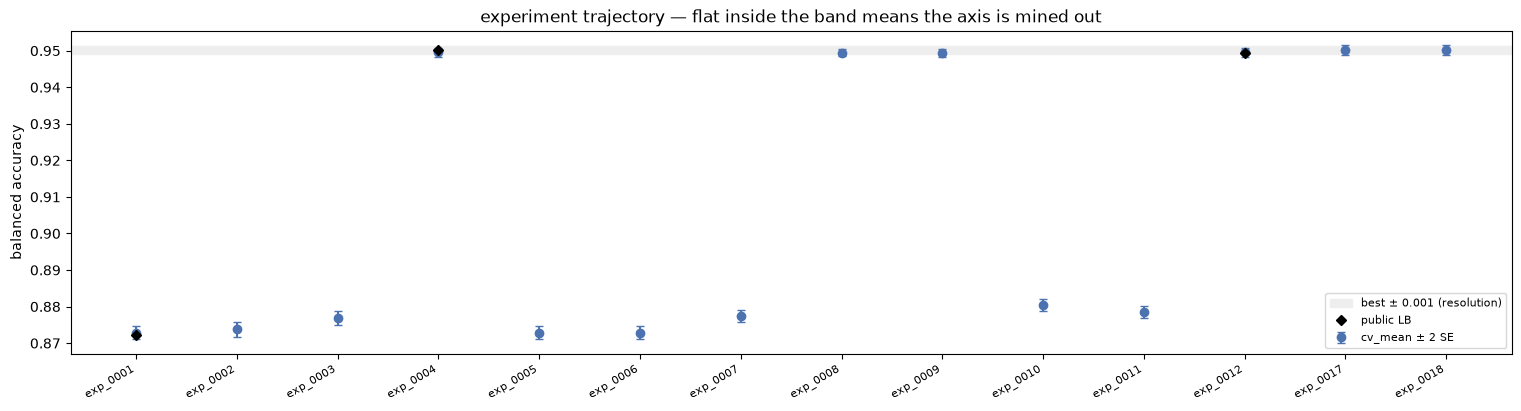

In [13]:
plots.experiment_compare(pl.read_csv(cv.LEDGER))

The picture to internalise: everything the ladder did lives in two clusters — argmax at
~0.873–0.880 and corrected at ~0.9495 — and inside each cluster the points are one
resolution apart. One decision moved between clusters; everything else moved within
them.

---
## 5. The escape clause fired — and what it bought

Two new information sources appeared after this notebook was first written, and neither
is a knob:

- **Notebook 06, section 4** measures genuine *exact-value* target signal in
  `sleep_duration`, `water_intake` and `heart_rate` — structure at single-value
  resolution, which a binned tree split cannot reach at any capacity. A new feature
  domain, arrived at by measurement.
- **The step-8 writeup review** (LEARNING.md) identified the FT-Transformer as the only
  measured source of error decorrelation in this competition — precisely what section 2
  proved this blend lacked.

Criterion 3 is what changed. Both are *readable* before they run, because each has a
mechanism and a prior effect size rather than a hope. The first has now been spent:

In [14]:
ledger = pl.read_csv(cv.LEDGER)
ledger.filter(pl.col("exp_id").is_in(["exp_0004", "exp_0017", "exp_0018"])).select(
    "exp_id", "cv_mean", "cv_std", "parent", "changed")

exp_id,cv_mean,cv_std,parent,changed
str,f64,f64,str,str
"""exp_0004""",0.94956,0.00138,"""exp_0001""","""class_weight=balanced (training-route prior correction)"""
"""exp_0017""",0.95014,0.00144,"""exp_0004""","""add 9 fold-fitted exact-value TE columns (3 columns x 3 classes)"""
"""exp_0018""",0.95017,0.00144,"""exp_0017""","""encode all 7 numeric columns instead of the 3 the replication test kept"""


**`exp_0017`: +0.00059 at t = 7.2, five of five folds positive** — the first score above
the tie band and the largest readable gain since the prior correction itself.
**`exp_0018`: +0.00003 at t = 0.4** — encoding the four columns the replication test
rejected buys nothing, which validates the screen rather than the score.

Where that leaves the gap to the top: our private 0.94979 sat ~0.0011 below the winning
0.95085. This CV gain is ~half of it, and it is the same lever the 11th-place writeup
reported (+0.0007 on XGBoost). The other named source — one FT-Transformer for the
decorrelation the two-GBDT blend measurably lacks — is still unspent (`exp_0013`/`0014`
harness exists; it needs the Kaggle GPU run to finish).

**The stopping rule was right and the reopening was right, and neither contradicts the
other.** Criterion 3 declines experiments you could not read. `exp_0017` was declinable
in August because nobody had measured that the signal existed; once the measurement
existed, the experiment became readable and won on the first try. That is the difference
between stopping and giving up: *stop when you are out of information sources, not when
you are out of ideas* — ideas are unlimited and mostly worthless, sources are countable.

Notebook 08 turns picks into files.